<a href="https://colab.research.google.com/github/shadynagy111-eng/Decoding-EGX-Price-Action/blob/Dataset-Generation/Dataset_Generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#create folder
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplfinance as mpf

base_path = '/content/dataset/'
image_types = ['candlestick', 'gaf']
labels = ['bullish', 'bearish', 'neutral']

for img_type in image_types:
    for label in labels:
        dir_path = os.path.join(base_path, img_type, label)
        os.makedirs(dir_path, exist_ok=True)

print(f'Directory structure created at {base_path}')

pyts is available
Directory structure created at /content/dataset/


In [ ]:
#clear the folder

import os

base_path = '/content/dataset/'
image_types = ['candlestick', 'gaf']
labels = ['bullish', 'bearish', 'neutral']

files_removed = 0
for img_type in image_types:
    for label in labels:
        dir_path = os.path.join(base_path, img_type, label)
        if os.path.exists(dir_path):
            for filename in os.listdir(dir_path):
                file_path = os.path.join(dir_path, filename)
                try:
                    if os.path.isfile(file_path):
                        os.remove(file_path)
                        files_removed += 1
                except Exception as e:
                    print(f'Error deleting {file_path}: {e}')

print(f'Dataset directories cleared. Total files removed: {files_removed}')

Dataset directories cleared. Total files removed: 0


## Refined CULR Processing and Labeling

### Subtask:
Load the stock data, calculate CULR components, and segment the data into 20-day windows with updated classification labels and ticker metadata.


In [ ]:
import pandas as pd
import numpy as np
import os

# 1. Define ticker name from filename
file_path = '/content/MFPC_price.csv'
ticker = os.path.basename(file_path).split('_')[0]

# 2. Load CSV and prepare data
df = pd.read_csv(file_path)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# 3. Calculate CULR components
df['C'] = df['Close']
df['U'] = df['High'] - df[['Open', 'Close']].max(axis=1)
df['L'] = df[['Open', 'Close']].min(axis=1) - df['Low']
df['R'] = df['Close'] - df['Open']

# 4. Sliding window and labeling
window_size = 20
processed_windows = []

for i in range(len(df) - window_size + 1):
    window_df = df.iloc[i : i + window_size].copy()

    # Calculate price change percentage
    start_price = window_df['Close'].iloc[0]
    end_price = window_df['Close'].iloc[-1]
    price_change = (end_price - start_price) / start_price

    # 5. Apply refined labeling logic
    if abs(price_change) <= 0.01:
        label = 'neutral'
    elif price_change > 0.0275:
        label = 'bullish'
    elif price_change < -0.0275:
        label = 'bearish'
    else:
        # Skip windows that don't fit the defined thresholds
        continue

    # 6. Store processed windows with metadata
    processed_windows.append({
        'data': window_df,
        'label': label,
        'ticker': ticker,
        'start_date': window_df['Date'].iloc[0],
        'end_date': window_df['Date'].iloc[-1]
    })

label_series = pd.Series([w['label'] for w in processed_windows])
print(f'Ticker: {ticker}')
print(f'Processed {len(processed_windows)} windows.')
print('Label distribution:')
print(label_series.value_counts())

Ticker: MFPC
Processed 1910 windows.
Label distribution:
bullish    931
bearish    794
neutral    185
Name: count, dtype: int64


In [ ]:
import os

def list_files(startpath):
    for root, dirs, files in os.walk(startpath):
        level = root.replace(startpath, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/ - ({len(files)} files)')

base_path = '/content/drive/MyDrive/23-GP26-Seif-AI4FinEGX/Datasets/dataset'
if os.path.exists(base_path):
    print(f'Contents of {base_path}:')
    list_files(base_path)
else:
    print(f'Directory {base_path} not found.')

Contents of /content/drive/MyDrive/23-GP26-Seif-AI4FinEGX/Datasets/dataset:
dataset/ - (0 files)
    candlestick/ - (0 files)
        neutral/ - (2597 files)
        bearish/ - (8481 files)
        bullish/ - (10796 files)
    gaf/ - (0 files)
        neutral/ - (2597 files)
        bearish/ - (8481 files)
        bullish/ - (10796 files)


In [ ]:
from pyts.image import GramianAngularField
import matplotlib.pyplot as plt
import numpy as np
import os
import mplfinance as mpf

# 1. Initialize GASF
gasf = GramianAngularField(method='summation')

for idx, window in enumerate(processed_windows):
    win_df = window['data']
    label = window['label']
    ticker = window['ticker']
    timestamp = window['start_date'].strftime('%Y%m%d')
    # Naming convention: [ticker]_window_[idx]_[timestamp]
    base_filename = f'{ticker}_window_{idx}_{timestamp}'

    # 2. Generate 4-channel GASF
    culr_data = win_df[['C', 'U', 'L', 'R']].values.T
    # Scale data to [-1, 1]
    culr_min = culr_data.min(axis=1, keepdims=True)
    culr_max = culr_data.max(axis=1, keepdims=True)
    scaled_culr = 2 * (culr_data - culr_min) / (culr_max - culr_min + 1e-8) - 1
    gaf_images = gasf.fit_transform(scaled_culr)

    # Save GASF as .npy
    gaf_dir = os.path.join(base_path, 'gaf', label)
    np.save(os.path.join(gaf_dir, f'{base_filename}.npy'), gaf_images)

    # 3. Generate Candlestick Chart
    candle_df = win_df[['Open', 'High', 'Low', 'Close']].copy()
    candle_df.index = win_df['Date']

    candle_dir = os.path.join(base_path, 'candlestick', label)
    candle_path = os.path.join(candle_dir, f'{base_filename}.png')

    # Setup clean plot
    fig, ax = plt.subplots(figsize=(1, 1), dpi=100)
    mpf.plot(candle_df, type='candle', ax=ax, style='charles', update_width_config=dict(candle_linewidth=0.5))
    ax.set_axis_off()

    # Save and close
    plt.savefig(candle_path, bbox_inches='tight', pad_inches=0, transparent=False)
    plt.close(fig)

print(f'Successfully generated and saved {len(processed_windows)} GASF and candlestick files.')

Successfully generated and saved 1910 GASF and candlestick files.


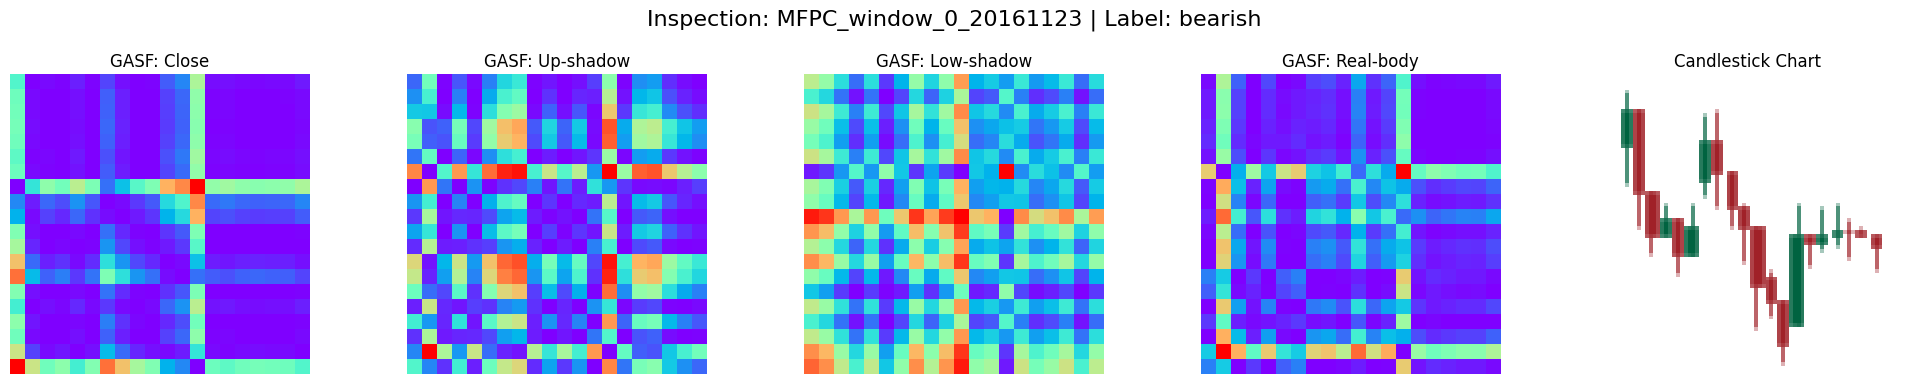

In [ ]:
import matplotlib.image as mpimg

# 1. Select a sample window (the first one)
sample_idx = 0
sample_win = processed_windows[sample_idx]
label = sample_win['label']
ticker = sample_win['ticker']
timestamp = sample_win['start_date'].strftime('%Y%m%d')
base_filename = f'{ticker}_window_{sample_idx}_{timestamp}'

# 2. Retrieve saved data
gaf_path = os.path.join(base_path, 'gaf', label, f'{base_filename}.npy')
candle_path = os.path.join(base_path, 'candlestick', label, f'{base_filename}.png')

gaf_data = np.load(gaf_path)
candle_img = mpimg.imread(candle_path)

# 3. Create figure with 1 row and 5 columns
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
channels = ['Close', 'Up-shadow', 'Low-shadow', 'Real-body']

# 4. Display 4 GASF channels
for i in range(4):
    im = axes[i].imshow(gaf_data[i], cmap='rainbow', origin='lower')
    axes[i].set_title(f'GASF: {channels[i]}')
    axes[i].axis('off')

# 5. Display Candlestick Chart
axes[4].imshow(candle_img)
axes[4].set_title('Candlestick Chart')
axes[4].axis('off')

# 6. Set main title
plt.suptitle(f'Inspection: {base_filename} | Label: {label}', fontsize=16)

# 7. Finalize layout and show
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()